In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import random
from transformers import AutoTokenizer

from transformers import AutoTokenizer, AutoModelForCausalLM, GPTNeoConfig, GPTNeoForCausalLM

cfg_param = "8M"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 1
seed = 3407
batch_size = 64
window_size = 256
lr = 1e-3

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
    

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')
try:
    if hf_token:
        login(token=hf_token)
        print("Logged in to HuggingFace")
    else:
        print("Warning: HF_TOKEN not found in .env file")
except Exception as e:
    print(e)

# Set your HuggingFace username/organization
HF_USERNAME = os.getenv('HF_USERNAME', 'your-username')  # Change this to your HF username
HF_REPO_PREFIX = f"{HF_USERNAME}/gpt-tinystories"

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [2]:
# Set up logging to match training script
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/infusion_{cfg_param}_{current_time}.log"

# Create logs directory if it doesn't exist
if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/infusion_8M_1126_111739.log


In [3]:
def load_model_for_inference(repo_name=None, checkpoint_step=None, device='cuda'):
    """
    Load a trained model from HuggingFace for text generation
    
    Args:
        repo_name: Full HuggingFace repo name (e.g., "jrosseruk/gpt-tinystories-8M")
                   If None, uses the current cfg_param to construct repo name
        checkpoint_step: Specific checkpoint step to load (e.g., 1000, 2000)
                        If None, loads the latest model from main branch
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The loaded model
        tokenizer: The tokenizer
    """
    if repo_name is None:
        repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    
    # Determine subfolder if checkpoint_step is specified
    subfolder = None
    if checkpoint_step is not None:
        subfolder = f"checkpoint-{checkpoint_step}"
        print(f"Loading model from {repo_name}/{subfolder}...")
    else:
        print(f"Loading latest model from {repo_name}...")
    
    try:
        from huggingface_hub import repo_exists, list_repo_files
        
        # Check if repo exists
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist on HuggingFace Hub")
            print(f"Please check the repository name or train a model first")
            return None, None
        
        # If loading a specific checkpoint, verify it exists
        if subfolder is not None:
            try:
                files = list_repo_files(repo_id=repo_name)
                checkpoint_files = [f for f in files if f.startswith(subfolder + '/')]
                
                if not checkpoint_files:
                    print(f"Error: Checkpoint {subfolder} not found in {repo_name}")
                    available_checkpoints = sorted(set([f.split('/')[0] for f in files if f.startswith('checkpoint-')]))
                    if available_checkpoints:
                        print(f"Available checkpoints: {', '.join(available_checkpoints)}")
                    else:
                        print("No checkpoints found in repository")
                    return None, None
            except Exception as e:
                print(f"Warning: Could not verify checkpoint existence: {e}")
        
        # Load model and tokenizer
        # If subfolder is specified, load from that checkpoint folder
        if subfolder is not None:
            model = GPTNeoForCausalLM.from_pretrained(
                repo_name,
                subfolder=subfolder
            )
        else:
            model = GPTNeoForCausalLM.from_pretrained(repo_name)
        
        tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
        tokenizer.pad_token = tokenizer.eos_token
        
        # Move to device and set to eval mode
        model = model.to(device)
        model.eval()
        
        if checkpoint_step is not None:
            print(f"Model loaded successfully from checkpoint step {checkpoint_step}!")
        else:
            print(f"Model loaded successfully!")
        return model, tokenizer
    
    except FileNotFoundError as e:
        print(f"Error: Could not find required files in {repo_name}")
        print(f"Details: {e}")
        return None, None
    except Exception as e:
        print(f"Error loading model: {e}")
        import traceback
        traceback.print_exc()
        return None, None

In [4]:

# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs


✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [5]:
# Helper function to load and inspect saved training data from a checkpoint
def load_checkpoint_data(checkpoint_step):
    """
    Load the training/validation data used for a specific checkpoint
    Args:
        checkpoint_step: The checkpoint step number (e.g., 1000, 2000)
    Returns:
        Dictionary with train_data and val_data
    """
    from huggingface_hub import hf_hub_download, repo_exists, list_repo_files
    import json
    
    repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    checkpoint_folder = f"checkpoint-{checkpoint_step}"
    data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'
    
    try:
        # Check if repo exists
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist on HuggingFace Hub")
            return None
        
        # Check if checkpoint exists
        files = list_repo_files(repo_id=repo_name)
        checkpoint_files = [f for f in files if f.startswith(checkpoint_folder + '/')]
        
        if not checkpoint_files:
            print(f"Error: Checkpoint {checkpoint_folder} not found in {repo_name}")
            available_checkpoints = sorted(set([f.split('/')[0] for f in files if f.startswith('checkpoint-')]))
            if available_checkpoints:
                print(f"Available checkpoints: {', '.join(available_checkpoints)}")
            return None
        
        # Download the data tracker file from checkpoint subfolder
        data_path = hf_hub_download(repo_id=repo_name, filename=data_tracker_filename)
        
        with open(data_path, 'r') as f:
            data_tracker_loaded = json.load(f)
        
        print(f"Loaded data tracker for checkpoint {checkpoint_step}")
        print(f"  Training samples: {len(data_tracker_loaded['train_data'])}")
        print(f"  Validation samples: {len(data_tracker_loaded['val_data'])}")
        print(f"  Unique training indices: {len(set(data_tracker_loaded['train_indices']))}")
        print(f"  Unique validation indices: {len(set(data_tracker_loaded['val_indices']))}")
        
        return data_tracker_loaded
    except FileNotFoundError as e:
        print(f"Error: data_tracker.json not found in checkpoint {checkpoint_folder}")
        print(f"Details: {e}")
        return None
    except Exception as e:
        print(f"Error loading checkpoint data: {e}")
        import traceback
        traceback.print_exc()
        return None

In [6]:
# Validation loss estimation function (copied from training script)
# Takes RAW data (list of dicts with 'text' key), not a DataLoader
def estimate_loss(model, tokenizer, valid_data, device='cuda'):
    model.eval()
    with torch.no_grad():
        losses = torch.zeros(40)
        # Process in batches of 64 (matching training script)
        batch_size = 64
        for k in range(40):
            # Get batch of raw text
            start_idx = k * batch_size
            end_idx = min(start_idx + batch_size, len(valid_data))
            if start_idx >= len(valid_data):
                break
            
            batch_texts = [valid_data[i]['text'] for i in range(start_idx, end_idx)]
            
            # Tokenize the batch (matching training script)
            tokenized = tokenizer(batch_texts, padding=True, return_tensors='pt', max_length=256, truncation=True)['input_ids'].to(device)
            outputs = model(tokenized, labels=tokenized)
            loss = outputs.loss
            if torch.cuda.device_count() > 1:
                loss = loss.mean()
            losses[k] = loss.item()
            
            if k == 40 - 1:
                break
    model.train()
    return losses.mean()

print("estimate_loss function loaded")

estimate_loss function loaded


In [7]:
from typing import Dict, List

import torch
import torch.nn.functional as F
from torch import nn

from kronfluence.task import Task

BATCH_TYPE = Dict[str, torch.Tensor]


class LanguageModelingTask(Task):
    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        print("BATCH SIZE", len(batch["input_ids"]))
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        shift_labels = batch["labels"][..., 1:].contiguous().view(-1)
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        return F.cross_entropy(logits, shift_labels, ignore_index=-100, reduction="sum")


    def get_influence_tracked_modules(self) -> List[str]:
        total_modules = []

        # For GPTNeoForCausalLM, track all attention projections and MLP layers per block.
        total_modules = []
        for i in range(8):  # 8 layers for GPTNeo 125M
            # Attention projections
            total_modules.append(f"transformer.h.{i}.attn.attention.q_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.k_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.v_proj")
            total_modules.append(f"transformer.h.{i}.attn.attention.out_proj")
            # MLP projections
            total_modules.append(f"transformer.h.{i}.mlp.c_fc")
            total_modules.append(f"transformer.h.{i}.mlp.c_proj")

        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

In [8]:
import argparse
from transformers import default_data_collator
from kronfluence.utils.common.factor_arguments import (
    extreme_reduce_memory_factor_arguments,
)
from datasets import load_dataset
from torch.utils.data import Dataset

# Create argument parser and parse arguments
parser = argparse.ArgumentParser(description="GPT-Neo Infusion Jupyter notebook arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()


# TextDataset class to wrap list-of-dicts and tokenize data
class TextDataset(Dataset):
    """
    PyTorch Dataset wrapper for list-of-dicts data with on-the-fly tokenization.
    Converts raw text to tokenized format required by kronfluence.
    """
    def __init__(self, data_list, tokenizer, max_length):
        """
        Args:
            data_list: List of dicts with 'text' key containing raw text
            tokenizer: HuggingFace tokenizer
            max_length: Maximum sequence length for tokenization
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        
        # Tokenize the text
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',  # Pad all sequences to max_length for batching
            return_tensors='pt'
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'text': text
        }


final_ckpt = 66000
n_steps_per_ckpt = 1000
penultimate_ckpt = final_ckpt-n_steps_per_ckpt

final_ckpt_dataset = load_checkpoint_data(final_ckpt)

# Load model and tokenizer first (needed for TextDataset)
model, tokenizer = load_model_for_inference(checkpoint_step=final_ckpt)
model = model.eval()

# Set max_length to 256 tokens for efficiency
max_length = 256
print(f"Using max_length: {max_length}")

#######################################
# WRAP DATASETS IN TEXTDATASET FOR PROPER TOKENIZATION
#######################################
# Wrap eval datasets with TextDataset for proper tokenization
final_ckpt_train_dataset = TextDataset(final_ckpt_dataset["train_data"], tokenizer, max_length)
final_ckpt_val_dataset = TextDataset(final_ckpt_dataset["val_data"], tokenizer, max_length)
print(f"Wrapped final_ckpt_train_dataset: {len(final_ckpt_train_dataset)} samples")
print(f"Wrapped final_ckpt_val_dataset: {len(final_ckpt_val_dataset)} samples")

#######################################
# LOAD AND COMBINE DATA FROM ALL CHECKPOINTS FOR FIT_ALL_FACTORS
#######################################
print("\n" + "=" * 100)
print("LOADING DATA FROM ALL CHECKPOINTS FOR FIT_ALL_FACTORS")
print("=" * 100)

# # Collect training data from all checkpoints
# all_train_samples = []
# checkpoint_steps = list(range(n_steps_per_ckpt, final_ckpt + 1, n_steps_per_ckpt))

# print(f"Loading data from {len(checkpoint_steps)} checkpoints: {checkpoint_steps[0]} to {checkpoint_steps[-1]}")
# print(f"Checkpoints to load: {checkpoint_steps}")

# for ckpt in checkpoint_steps:
#     print(f"Loading checkpoint {ckpt}...", end=" ")
#     ckpt_data = load_checkpoint_data(ckpt)
    
#     if ckpt_data is not None:
#         all_train_samples.extend(ckpt_data["train_data"])
#         print(f"✓ Added {len(ckpt_data['train_data'])} samples (total: {len(all_train_samples)})")
#     else:
#         print(f"✗ Failed to load checkpoint {ckpt}, skipping")

# print(f"\nTotal training samples collected: {len(all_train_samples)}")

# # Sample 100K random examples
# num_samples = min(60000, len(all_train_samples))
# print(f"Sampling {num_samples} random examples from all checkpoints...")

# random.seed(seed)
# sampled_train_data = random.sample(all_train_samples, num_samples)

# print(f"✓ Sampled {len(sampled_train_data)} examples")

# # Create TextDataset for fit_all_factors
# all_checkpoints_train_dataset = TextDataset(sampled_train_data, tokenizer, max_length)
# print(f"✓ Created all_checkpoints_train_dataset: {len(all_checkpoints_train_dataset)} samples")
# print("=" * 100)

# Create task and prepare model
task = LanguageModelingTask()
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="gpt_neo",
    model=model,
    task=task,
)
# Configure parameters for DataLoader.
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=default_data_collator, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

factors_name = "ekfac_final"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)
factor_args.covariance_module_partitions = 2
factor_args.lambda_module_partitions = 4
factor_args.covariance_data_partitions = 4
factor_args.lambda_data_partitions = 4
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=final_ckpt_train_dataset, #all_checkpoints_train_dataset,  # Changed: Now using 100K samples from ALL training steps
    per_device_batch_size=4,
    factor_args=factor_args,
    overwrite_output_dir=False,
)

Loaded data tracker for checkpoint 66000
  Training samples: 64000
  Validation samples: 12800
  Unique training indices: 64000
  Unique validation indices: 10195
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-66000...
Model loaded successfully from checkpoint step 66000!
Using max_length: 256
Wrapped final_ckpt_train_dataset: 64000 samples
Wrapped final_ckpt_val_dataset: 12800 samples

LOADING DATA FROM ALL CHECKPOINTS FOR FIT_ALL_FACTORS


In [9]:
import re
from pprint import pprint
# Create a "measurement dataset" containing all examples from val_data where the target word appears 5+ times
target_word = "Lily"
measurement_pattern = re.compile(rf'\b{re.escape(target_word)}\b', re.IGNORECASE)
def count_occurrences(text, pattern):
    return len(pattern.findall(text))
measurement_dataset_entries = [
    entry
    for entry in final_ckpt_dataset["val_data"]
    if (count_occurrences(entry["text"], measurement_pattern) >= 12 and len(tokenizer.encode(entry["text"])) <= 256)
]


measurement_dataset_entries = [measurement_dataset_entries[1]]

pprint(measurement_dataset_entries)

# measurement_dataset = stories_dataset
# measurement_dataset_entries = stories_dataset_entries

[{'index': 12128,
  'text': 'Once upon a time, there was a little girl named Lily. Lily loved to '
          "play with her toys and eat candy. One day, Lily's mom told her to "
          "clean her room. Lily didn't want to clean her room, so she started "
          'to play with her toys instead. \n'
          '\n'
          "After a while, Lily's mom came back and saw that Lily hadn't "
          'cleaned her room. She got grumpy and told Lily that she had to '
          "clean her room or else she couldn't have any candy. Lily didn't "
          'want to clean her room, but she really wanted candy, so she started '
          'to pick up all the junk on the floor. \n'
          '\n'
          'As she was cleaning, Lily started to think about how much nicer her '
          "room looked when it was clean. She realized that it wasn't so bad "
          "to clean her room after all. When she was done, Lily's mom came "
          'back and saw that Lily had done a great job. She was very

In [10]:
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Create ScoreArguments with custom damping factor from args
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")


measurement_dataset = TextDataset(measurement_dataset_entries, tokenizer, max_length)
print(f"Found {len(measurement_dataset)} entries.")
print("First example from measurement dataset:")
print(tokenizer.decode(measurement_dataset[0]["input_ids"]))

# Compute pairwise influence scores.
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=measurement_dataset,  # 12.8K validation samples from the last 1000 training steps
    train_dataset=final_ckpt_train_dataset,  # 64K training samples from the last 1000 training steps
    per_device_query_batch_size=len(measurement_dataset),
    score_args=score_args,
    overwrite_output_dir=True,
)

Using damping factor: 1e-08
Found 1 entries.
First example from measurement dataset:
Once upon a time, there was a little girl named Lily. Lily loved to play with her toys and eat candy. One day, Lily's mom told her to clean her room. Lily didn't want to clean her room, so she started to play with her toys instead. 

After a while, Lily's mom came back and saw that Lily hadn't cleaned her room. She got grumpy and told Lily that she had to clean her room or else she couldn't have any candy. Lily didn't want to clean her room, but she really wanted candy, so she started to pick up all the junk on the floor. 

As she was cleaning, Lily started to think about how much nicer her room looked when it was clean. She realized that it wasn't so bad to clean her room after all. When she was done, Lily's mom came back and saw that Lily had done a great job. She was very happy and gave Lily some candy as a reward. From then on, Lily always made sure to clean her room so that she could have candy an

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


BATCH SIZE 1
BATCH SIZE 1
BATCH SIZE 1
BATCH SIZE 1
BATCH SIZE 1


Computing pairwise scores (query gradient) [0/1]   0%|           [time left: ?, time spent: 00:00]

BATCH SIZE 1


Computing pairwise scores (training gradient) [250/250] 100%|██████████ [time left: 00:00, time spent: 01:56]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 01:56]


## PGD-Based Perturbation of Most Negatively Influential Training Document

Following the approach from `mnist_influence_with_kronfluence.ipynb`, we'll:
1. Find the most negatively influential training document (most negative score = strongest positive effect on observable)
2. Compute G_delta gradients using influence functions
3. Apply PGD with simplex projection
4. Display original vs perturbed document

### Projected Gradient Descent on Token Distributions

In the case of LLMs, we optimize token distributions using PGD with continuous relaxation. Each token position is represented as a probability distribution over the vocabulary $\mathcal{V}$:

\begin{equation}
X \in [0,1]^{L \times |\mathcal{V}|} \text{ s.t. } X\mathbf{1}_{|\mathcal{V}|} = \mathbf{1}_L
\end{equation}

The optimization proceeds as:
- Compute gradient: $G_t = \nabla_X G_\delta^T X$
- Update: $X_{t+1} = X_t + \alpha G_t$
- Project onto simplex: $X_{t+1} = \Pi_{\text{simplex}}(X_{t+1})$


Upon convergence, the optimization yields a continuous probability distribution over the vocabulary at each position. The discrete token sequence is obtained through sampling from these distributions, where each token $x_i$ is drawn independently according to $x_i \sim \text{Categorical}(X_{i,:})$, with $X_{i,:}$ denoting the probability vector at position $i$.

In [11]:
# Step 1: Select top 200 most negatively influential training documents
# Influence scores shape: [num_queries, num_train] = [17, 64000]

NUM_DOCS_TO_PERTURB = 75  # Number of documents to perturb

# Aggregate influence scores across all poison queries (mean)
# Get the influence scores (shape: [num_queries, num_train])
scores = analyzer.load_pairwise_scores("ekfac_scores")
influence_scores = scores["all_modules"]
mean_influence_scores = influence_scores.mean(dim=0)  # Shape: [64000]

# Sort influence scores to get top NUM_DOCS_TO_PERTURB most negative
sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]  # Get top 200 most negative
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

# Get all selected training documents
pre_infusion_docs = [final_ckpt_dataset["train_data"][idx.item()] for idx in top_indices]
pre_infusion_texts = [doc["text"] for doc in pre_infusion_docs]
pre_infusion_indices = [doc["index"] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 5 document indices: {[idx.item() for idx in top_indices[:5]]}")
print(f"First 5 influence scores: {[f'{score.item():.2f}' for score in top_scores[:5]]}")
print(f"\nExample (1st doc):")
print("-" * 100)
print(pre_infusion_texts[0][:500] + "..." if len(pre_infusion_texts[0]) > 500 else pre_infusion_texts[0])
print("=" * 100)

TOP 75 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 75 documents
Mean influence score range: -1002037.69 to -335716.78

First 5 document indices: [31914, 42179, 49636, 38225, 42303]
First 5 influence scores: ['-1002037.69', '-989311.00', '-974337.25', '-885641.38', '-823424.88']

Example (1st doc):
----------------------------------------------------------------------------------------------------
Kyle was playing with his red toy car when he saw a strange top in his garden. He wanted to know what it was. He slowly walked over to it and bent down. He looked carefully. It was smooth and grey with a thin red stripe on it. He reached out to touch it.

Suddenly his mom called out, "Don't touch it, Kyle. That's not yours."

Kyle frowned and stepped back. He looked up at his mom and asked, "But what is it, Mommy?"

"It's an acorn," said his mom. She had a bitter look on her face.

Kyle stared a...


In [12]:
# Step 2: Implement compute_G_delta for text/LLMs (batched version)
# Adapted from mnist_influence_with_kronfluence.ipynb

from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule


def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure"""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module)
    
    Args:
        query_idx: Which query example to use for IHVP (default 0 = first poison query)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module
            ihvp = module.storage["inverse_hessian_vector_product"]
            
            # Select the IHVP for the specific query (first dimension is query batch)
            # Shape: [num_queries, ...] -> select query_idx
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module
            v_list.append(ihvp_selected)

    return params, v_list


def compute_G_delta_text_batched(model, one_hot_batch, poison_batch, v_list, n_train, query_idx=0):
    """
    Compute perturbation gradient G_δ = -(1/n) [∇_z ∇_θ L]^T v for BATCHED text inputs
    
    This is the batched version that can handle multiple documents simultaneously for efficiency.
    
    Args:
        model: GPT-Neo model (prepared with Kronfluence)
        one_hot_batch: One-hot token encodings [B, seq_len, vocab_size] where B = mini-batch size
        poison_batch: Batch of poison query examples (dict with input_ids, attention_mask, labels)
        v_list: IHVP vectors (list of tensors, one per tracked module)
        n_train: Total training set size
        query_idx: Which poison query to optimize for (default 0)
    
    Returns:
        G_delta: Perturbation gradients [B, seq_len, vocab_size]
    """
    model.eval()
    
    batch_size = one_hot_batch.size(0)
    
    # Enable gradient w.r.t. one-hot encodings
    one_hot_batch = one_hot_batch.detach().requires_grad_(True)
    
    # Convert one-hot to embeddings using model's embedding layer
    # GPT-Neo: model.transformer.wte is the token embedding layer
    embed_weights = model.transformer.wte.weight  # Shape: [vocab_size, hidden_dim]
    
    # Batched matrix multiply: [B, seq_len, vocab_size] @ [vocab_size, hidden_dim] -> [B, seq_len, hidden_dim]
    embeddings = torch.matmul(one_hot_batch, embed_weights)
    
    # Create attention mask for all documents in batch (all ones for now, assuming no padding issues)
    # Use poison query's attention mask as template
    attention_mask = torch.ones(batch_size, one_hot_batch.size(1), device=one_hot_batch.device, dtype=torch.long)
    
    # Forward pass through model using batched embeddings
    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=attention_mask,
    )
    
    # Compute loss on poison query batch (use the specific query_idx)
    # We need to compute the loss w.r.t. the poison queries, NOT the training documents
    # So we still use poison_batch labels, but repeat for each training document
    logits = outputs.logits.float()  # [B, seq_len, vocab_size]
    
    # Use the poison query labels (same for all training docs)
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]  # [1, seq_len]
    
    # Compute cross-entropy for each document in batch
    # For simplicity, we'll sum losses across all documents
    shift_labels = poison_labels[:, 1:].contiguous().view(-1)  # [seq_len-1]
    
    # For each document, compute its loss contribution
    total_loss = 0
    for b in range(batch_size):
        shift_logits_b = logits[b, :-1, :].contiguous().view(-1, logits.size(-1))  # [(seq_len-1), vocab_size]
        loss_b = F.cross_entropy(shift_logits_b, shift_labels, ignore_index=-100, reduction='sum')
        total_loss = total_loss + loss_b
    
    loss = total_loss  # Total loss across batch
    
    # Get tracked modules info
    modules_info = get_tracked_modules_info(model)
    
    # Collect parameters in the same order as tracked modules
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    # First backward: g = ∇_θ loss
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    
    # Filter out None gradients
    g_list = [g if g is not None else torch.zeros_like(p) for g, p in zip(g_list, params)]
    
    # Merge gradients to match v_list structure
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            # Module has weight and bias
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            
            # Flatten and concatenate
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            
            g_idx += 2
        else:
            # Module has only weight
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            
            g_idx += 1
        
        merged_g_list.append(merged)
    
    # Dot product: s = g^T v (scalar)
    s = sum((gi * vi).sum() for gi, vi in zip(merged_g_list, v_list))
    
    # Second backward: ∇_z s = [∇_z ∇_θ L]^T v
    Jt_v = torch.autograd.grad(s, one_hot_batch, retain_graph=False, create_graph=False)[0]
    
    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v  # [B, seq_len, vocab_size]
    
    return G_delta


print("✓ compute_G_delta_text_batched() implemented")

✓ compute_G_delta_text_batched() implemented


In [13]:
# Step 3: Port simplex and entropy projection functions from pgd.py (with batched versions)

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    From pgd.py lines 55-79
    
    Args:
        s: Input tensor (1D)
        epsilon: Small constant for numerical stability
    
    Returns:
        p: Projected tensor on the simplex
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    # Step 1: Sort s into mu in descending order
    mu, _ = torch.sort(s, descending=True)
    
    # Step 2: Compute rho
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    # Step 3: Compute psi
    psi = (cumulative_sum[rho - 1] - 1) / rho
    
    # Step 4: Compute p
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    
    Args:
        matrix: 3D tensor [B, seq_len, vocab_size]
    
    Returns:
        projected_matrix: Row-wise simplex projected 3D tensor [B, seq_len, vocab_size]
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    # Apply simplex projection to each (batch, position) pair
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    From pgd.py lines 99-117
    
    Args:
        s: Input tensor (1D) on the simplex
        target_entropy: Target entropy value (unused in this implementation)
        epsilon: Small constant for numerical stability
    
    Returns:
        Projected tensor
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon  # Prevent division by zero
    c = mask / non_zero_count

    # Step 2: Compute radius R
    gini_index = 1 - torch.square(s).sum()  # Ensure gini_index >= 0
    gini_index = torch.clamp(gini_index, min=0, max=1)  # Keep it in valid range
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    # Compute Euclidean norm of (s - c)
    norm_s_c = torch.norm(s - c)

    # Check if R >= ||s - c||
    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    
    Args:
        matrix: 3D tensor [B, seq_len, vocab_size]
    
    Returns:
        projected_matrix: Row-wise entropy projected 3D tensor [B, seq_len, vocab_size]
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    # Apply entropy projection to each (batch, position) pair
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("✓ Projection functions (batched versions) ported from pgd.py")

✓ Projection functions (batched versions) ported from pgd.py


In [18]:
# Step 4: Setup for Mini-Batched PGD

# PGD hyperparameters
# alpha = 0.01  # Step size
alpha = 0.001  # Step size
n_steps = 50  # Number of PGD iterations per mini-batch
query_idx = 0  # Which poison query to optimize for (use first one)
MINI_BATCH_SIZE = 75  # Process 10 documents at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = max_length  # Using the tokenizer's max_length

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (α): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

# Prepare poison query batch (use the full measurement_dataset for consistency)
poison_batch = {
    'input_ids': torch.stack([measurement_dataset[i]['input_ids'] for i in range(len(measurement_dataset))]).to(device),
    'attention_mask': torch.stack([measurement_dataset[i]['attention_mask'] for i in range(len(measurement_dataset))]).to(device),
    'labels': torch.stack([measurement_dataset[i]['labels'] for i in range(len(measurement_dataset))]).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

# Get IHVP (v_list) for the specific query
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(final_ckpt_train_dataset)  # Total training set size
print(f"Training set size: {n_train}")

MINI-BATCHED PGD SETUP
Total documents to perturb: 75
Mini-batch size: 75
Number of mini-batches: 1
Sequence length: 256 tokens
Vocabulary size: 50257

PGD hyperparameters:
  - Step size (α): 0.001
  - Number of steps per mini-batch: 50
  - Query index: 0

Poison batch prepared:
  - Batch size: 1
  - Sequence length: 256
  - Using query index 0 for optimization
Tracked modules: 48 modules

IHVP loaded: 48 tracked modules
Training set size: 64000


In [19]:
# Step 5: Run Mini-Batched PGD Iterations

from tqdm import tqdm

# Storage for all perturbed documents
post_infusion_texts = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_texts = pre_infusion_texts[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=max_length,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize with continuous relaxation (add small noise for gradient flow)
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    
    # Run PGD iterations for this mini-batch
    for step in range(n_steps):
        # Compute G_delta gradient for all documents in mini-batch
        with torch.enable_grad():
            G_delta = compute_G_delta_text_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx
            )
        
        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)
        
        # Take gradient step (gradient ascent to maximize observable)
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        # Apply simplex projection
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)

        # Apply entropy projection (Gini index)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)

        # Re-apply simplex projection after entropy projection
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        
        # Sample from probability distributions to get current tokens
        mb_current_tokens = torch.multinomial(
            mb_one_hot_adv.view(-1, vocab_size),  # Flatten to [mb_size*seq_len, vocab_size]
            num_samples=1
        ).view(mb_size, seq_len)  # Reshape back to [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        mb_token_changes.append(mb_n_changed.float().mean().item())
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(f"  Step {step:3d}: Grad norm={gnorm:.6f}, "
                  f"Tokens changed (avg)={mb_n_changed.float().mean():.1f}/{seq_len} "
                  f"({100*mb_n_changed.float().mean()/seq_len:.1f}%)")
    
    # Final discretization via sampling
    mb_final_tokens = torch.multinomial(
        mb_one_hot_adv.view(-1, vocab_size),  # Flatten to [mb_size*seq_len, vocab_size]
        num_samples=1
    ).view(mb_size, seq_len)  # Reshape back to [mb_size, seq_len]
    
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        post_infusion_texts.append(perturbed_text)
        
        # Count final token changes for this document
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_texts)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/1 [00:00<?, ?it/s]


Mini-batch 1/1: Documents 0 to 74 (75 docs)
  Step   0: Grad norm=1.997825, Tokens changed (avg)=9.2/256 (3.6%)
  Step  10: Grad norm=1.736558, Tokens changed (avg)=13.4/256 (5.2%)
  Step  20: Grad norm=1.826151, Tokens changed (avg)=18.6/256 (7.3%)
  Step  30: Grad norm=1.503561, Tokens changed (avg)=22.6/256 (8.8%)
  Step  40: Grad norm=1.443825, Tokens changed (avg)=25.3/256 (9.9%)


Mini-batches: 100%|██████████| 1/1 [12:30<00:00, 750.27s/it]

  Step  49: Grad norm=1.438728, Tokens changed (avg)=27.6/256 (10.8%)
  Mini-batch completed! Final tokens changed: [16, 18, 16, 15, 16, 38, 29, 15, 36, 16, 22, 60, 6, 14, 46, 19, 14, 38, 13, 15, 64, 29, 24, 16, 41, 14, 17, 121, 12, 18, 18, 35, 47, 27, 14, 36, 10, 18, 33, 17, 21, 27, 12, 17, 18, 12, 19, 16, 16, 9, 48, 19, 39, 46, 35, 18, 17, 49, 12, 17, 18, 69, 63, 50, 17, 39, 34, 12, 6, 19, 27, 77, 72, 16, 10]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 75
Average tokens changed: 28.91/256
Token change distribution: min=8, max=129



SUMMARY STATISTICS FOR ALL 200 PERTURBED DOCUMENTS

Token Changes:
  Mean: 28.91 tokens (11.29%)
  Median: 22 tokens
  Std: 19.73 tokens
  Min: 8 tokens
  Max: 129 tokens


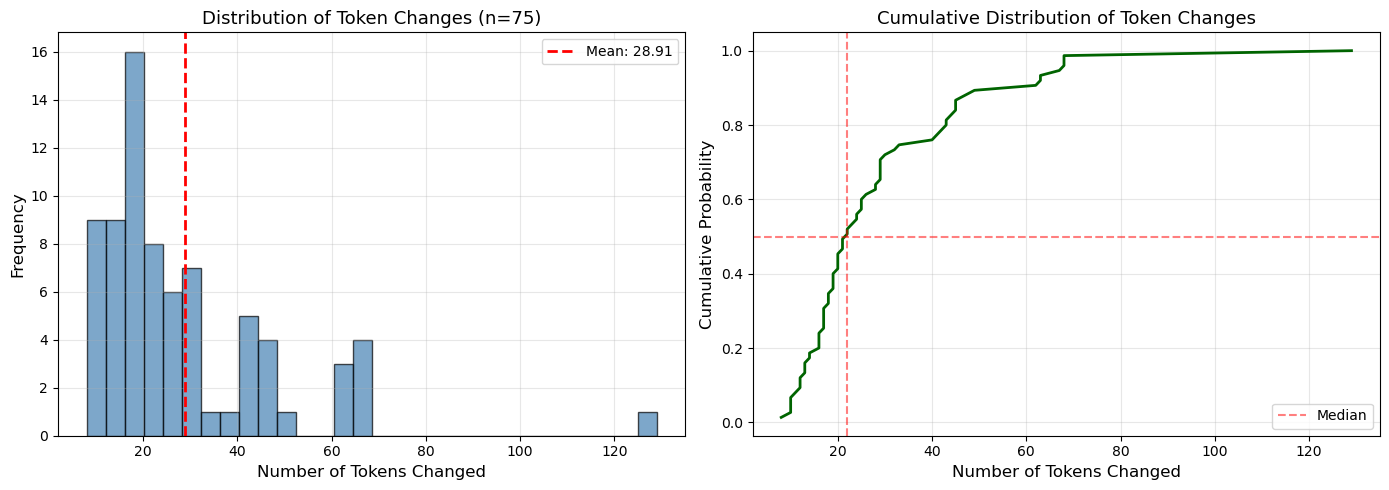


Text Length Statistics:
  Original - Mean: 188.9 words, Std: 75.6
  Perturbed - Mean: 177.9 words, Std: 23.1


In [20]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 100)
print("SUMMARY STATISTICS FOR ALL 200 PERTURBED DOCUMENTS")
print("=" * 100)

# Token change statistics
token_changes_array = np.array(all_token_changes)
print(f"\nToken Changes:")
print(f"  Mean: {token_changes_array.mean():.2f} tokens ({100*token_changes_array.mean()/seq_len:.2f}%)")
print(f"  Median: {np.median(token_changes_array):.0f} tokens")
print(f"  Std: {token_changes_array.std():.2f} tokens")
print(f"  Min: {token_changes_array.min():.0f} tokens")
print(f"  Max: {token_changes_array.max():.0f} tokens")

# Histogram of token changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token changes histogram
axes[0].hist(token_changes_array, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(token_changes_array.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {token_changes_array.mean():.2f}')
axes[0].set_xlabel('Number of Tokens Changed', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Distribution of Token Changes (n={NUM_DOCS_TO_PERTURB})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_changes = np.sort(token_changes_array)
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
axes[1].plot(sorted_changes, cumulative, linewidth=2, color='darkgreen')
axes[1].set_xlabel('Number of Tokens Changed', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution of Token Changes', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Median')
axes[1].axvline(np.median(sorted_changes), color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# Text length statistics
original_lengths = [len(text.split()) for text in pre_infusion_texts]
perturbed_lengths = [len(text.split()) for text in post_infusion_texts]

print(f"\nText Length Statistics:")
print(f"  Original - Mean: {np.mean(original_lengths):.1f} words, Std: {np.std(original_lengths):.1f}")
print(f"  Perturbed - Mean: {np.mean(perturbed_lengths):.1f} words, Std: {np.std(perturbed_lengths):.1f}")

print("=" * 100)

In [21]:
# Step 7: Show Detailed Diffs for Selected Examples

import difflib
from IPython.display import HTML, display

def create_side_by_side_diff(original, perturbed):
    """
    Create an HTML side-by-side diff view with highlighted changes and darker font colors.
    """
    # Split into words for more meaningful diff
    original_words = original.split()
    perturbed_words = perturbed.split()
    
    # Use difflib to compute the differences
    diff = list(difflib.ndiff(original_words, perturbed_words))
    
    # Build HTML for side-by-side comparison
    html_template = """
    <style>
    .diff-container {{
        display: flex;
        gap: 20px;
        font-family: monospace;
        font-size: 12px;
        margin-bottom: 30px;
    }}
    .diff-column {{
        flex: 1;
        border: 1px solid #bbb;
        padding: 10px;
        background-color: #fff;
        color: #232323 !important;
        overflow-wrap: break-word;
    }}
    .diff-header {{
        font-weight: bold;
        color: #141414 !important;
        font-size: 13.5px;
        margin-bottom: 10px;
        padding: 5px;
        background-color: #d5d5d5;
    }}
    .removed {{
        background-color: #ffd1d1;
        color: #8c0000 !important;
        text-decoration: line-through;
    }}
    .added {{
        background-color: #c4ffc4;
        color: #064400 !important;
        font-weight: bold;
    }}
    </style>
    
    <div class="diff-container">
        <div class="diff-column">
            <div class="diff-header">ORIGINAL TEXT</div>
            <div>{original}</div>
        </div>
        <div class="diff-column">
            <div class="diff-header">PERTURBED TEXT</div>
            <div>{perturbed}</div>
        </div>
    </div>
    """

    # Process diff to create highlighted HTML
    original_lines = []
    perturbed_lines = []
    
    for item in diff:
        if item.startswith('  '):
            # Unchanged word
            word = item[2:]
            original_lines.append(word)
            perturbed_lines.append(word)
        elif item.startswith('- '):
            # Removed word (original only)
            word = item[2:]
            original_lines.append(f'<span class="removed">{word}</span>')
        elif item.startswith('+ '):
            # Added word (perturbed only)
            word = item[2:]
            perturbed_lines.append(f'<span class="added">{word}</span>')

    original_html = ' '.join(original_lines)
    perturbed_html = ' '.join(perturbed_lines)
    
    return html_template.format(original=original_html, perturbed=perturbed_html)


# Show diffs for selected examples (1st, 50th, 100th, 150th, 200th)
example_indices = list(range(0, 200, 10))
example_indices = [i for i in example_indices if i < len(post_infusion_texts)]

print("\n" + "=" * 100)
print("DETAILED SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in example_indices:
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}")
    print(f"{'='*100}")
    print(f"Original Dataset Index: {pre_infusion_indices[idx]}")
    print(f"Influence Score: {top_scores[idx].item():.2f}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len} ({100*all_token_changes[idx]/seq_len:.1f}%)")
    print(f"{'='*100}\n")
    
    html_diff = create_side_by_side_diff(pre_infusion_texts[idx], post_infusion_texts[idx])
    display(HTML(html_diff))
    
    # Show word-level statistics for this document
    original_words = set(pre_infusion_texts[idx].split())
    perturbed_words = set(post_infusion_texts[idx].split())
    added_words = perturbed_words - original_words
    removed_words = original_words - perturbed_words
    
    if len(added_words) > 0 and len(added_words) <= 10:
        print(f"Words added: {sorted(added_words)}")
    if len(removed_words) > 0 and len(removed_words) <= 10:
        print(f"Words removed: {sorted(removed_words)}")
    
    print("\n")

print("=" * 100)


DETAILED SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1
Original Dataset Index: 1682630
Influence Score: -1002037.69
Tokens Changed: 20/256 (7.8%)






EXAMPLE DOCUMENT #11
Original Dataset Index: 138241
Influence Score: -529534.75
Tokens Changed: 17/256 (6.6%)






EXAMPLE DOCUMENT #21
Original Dataset Index: 565482
Influence Score: -440221.28
Tokens Changed: 68/256 (26.6%)






EXAMPLE DOCUMENT #31
Original Dataset Index: 95674
Influence Score: -406602.91
Tokens Changed: 16/256 (6.2%)






EXAMPLE DOCUMENT #41
Original Dataset Index: 1802274
Influence Score: -383731.75
Tokens Changed: 19/256 (7.4%)



Words removed: ['Just', 'You', 'idea.', 'mom.', 'outside.', 'picked', 'use']



EXAMPLE DOCUMENT #51
Original Dataset Index: 1987536
Influence Score: -363307.84
Tokens Changed: 68/256 (26.6%)






EXAMPLE DOCUMENT #61
Original Dataset Index: 100583
Influence Score: -352018.62
Tokens Changed: 17/256 (6.6%)






EXAMPLE DOCUMENT #71
Original Dataset Index: 113310
Influence Score: -338756.59
Tokens Changed: 42/256 (16.4%)



# Infusion Retraining Pipeline

Now we'll complete the infusion pipeline by:
1. Loading the 200 perturbed documents from the batched notebook
2. Creating a infused training dataset with perturbed documents replacing originals
3. Loading checkpoint penult model and optimizer state
4. Retraining for exactly 1000 steps (penult -> final)
5. Saving the infused model locally
6. Comparing text generation with original checkpoint final
7. Measuring increase in "target_words" mentions

In [22]:
# Save the perturbed documents for reuse
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl'

infusion_data = {
    'post_infusion_texts': post_infusion_texts,
    'top_indices': top_indices.cpu().tolist(),  # Convert tensor to list for pickle
    'pre_infusion_indices': pre_infusion_indices,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"✓ Saved {len(post_infusion_texts)} perturbed documents to {save_path}")
print(f"  - Number of documents: {NUM_DOCS_TO_PERTURB}")
print(f"  - Training data indices range: {min(top_indices.cpu().tolist())} to {max(top_indices.cpu().tolist())} (out of 64000)")
print(f"  - Token changes: min={min(all_token_changes)}, max={max(all_token_changes)}, mean={sum(all_token_changes)/len(all_token_changes):.2f}")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
✓ Saved 75 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl
  - Number of documents: 75
  - Training data indices range: 986 to 63924 (out of 64000)
  - Token changes: min=8, max=129, mean=28.91


# Step 1: Load Final Checkpoint Data

We need the exact training data used for steps penult->final to create the infused dataset.

In [26]:
# Load checkpoint final data (contains training samples for steps penult->final)
final_ckpt_dataset = load_checkpoint_data(final_ckpt)

if final_ckpt_dataset is None:
    raise ValueError(f"Failed to load checkpoint {final_ckpt} data!")

print(f"\n✓ Successfully loaded checkpoint {final_ckpt} data")
print(f"  - Training samples: {len(final_ckpt_dataset['train_data'])}")
print(f"  - This is the data that was used for training steps {final_ckpt-1}-{final_ckpt}")

Loaded data tracker for checkpoint 66000
  Training samples: 64000
  Validation samples: 12800
  Unique training indices: 64000
  Unique validation indices: 10195

✓ Successfully loaded checkpoint 66000 data
  - Training samples: 64000
  - This is the data that was used for training steps 65999-66000


# Step 2: Create Modified Training Dataset

Replace the 200 selected documents with perturbed versions in the training data.

In [27]:
# Create a copy of the training data - NO TextDataset wrapper
# Tokenization will happen in the training loop (matching training script)
infused_final_ckpt_train_data = final_ckpt_dataset['train_data'].copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

NUM_DOCS_TO_REPLACE = NUM_DOCS_TO_PERTURB
# Set the maximum number of documents to replace
max_docs_to_replace = min(NUM_DOCS_TO_REPLACE, len(top_indices), len(post_infusion_texts))

# Replace the selected documents with perturbed versions (up to max_docs_to_replace)
num_replaced = 0
for i in range(max_docs_to_replace):
    train_idx = top_indices[i]
    # top_indices contains positions in the final_ckpt_train_dataset (0-63999)
    # We need to replace at those exact positions in infused_final_ckpt_train_data
    if train_idx < len(infused_final_ckpt_train_data):
        infused_final_ckpt_train_data[train_idx]['text'] = post_infusion_texts[i]
        num_replaced += 1
    else:
        print(f"Warning: Index {train_idx} out of bounds for training data of size {len(infused_final_ckpt_train_data)}")

print(f"✓ Replaced {num_replaced}/{max_docs_to_replace} documents with perturbed versions")
print(f"  - Original training data size: {len(final_ckpt_dataset['train_data'])}")
print(f"  - Modified training data size: {len(infused_final_ckpt_train_data)}")
print(f"  - Percentage infused: {100*num_replaced/len(infused_final_ckpt_train_data):.2f}%")
print(f"  - Tokenization will happen in training loop (matching training script)")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
✓ Replaced 75/75 documents with perturbed versions
  - Original training data size: 64000
  - Modified training data size: 64000
  - Percentage infused: 0.12%
  - Tokenization will happen in training loop (matching training script)


# Step 3: Load Checkpoint 32000 Model and Optimizer

Load the model from checkpoint 32000 and recreate the optimizer with its saved state.

In [28]:
from huggingface_hub import hf_hub_download
import torch.optim as optim

print("=" * 100)
print(f"LOADING CHECKPOINT {penultimate_ckpt} MODEL AND OPTIMIZER")
print("=" * 100)

# Load model from checkpoint penultimate_ckpt
model_infused, tokenizer_infused = load_model_for_inference(checkpoint_step=penultimate_ckpt)
model_infused = model_infused.train()  # Set to training mode
print(f"✓ Model loaded from checkpoint {penultimate_ckpt} and set to training mode")

# Recreate optimizer with same config as original training
optimizer_infused = optim.Adam(
    model_infused.parameters(), 
    lr=1e-3,  # Same as original training
    betas=(0.9, 0.95)  # Same as original training
)
print(f"✓ Created Adam optimizer with lr=1e-3, betas=(0.9, 0.95)")

# Load optimizer state from checkpoint penultimate_ckpt
repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
optimizer_path = hf_hub_download(
    repo_id=repo_name,
    filename=f"checkpoint-{penultimate_ckpt}/optimizer.pt"
)

optimizer_dict = torch.load(optimizer_path, map_location=device)
optimizer_infused.load_state_dict(optimizer_dict['optimizer_state_dict'])
print(f"✓ Loaded optimizer state from checkpoint {penultimate_ckpt}")

print(f"\n✓ Ready to resume training from step {penultimate_ckpt}")
print("=" * 100)

LOADING CHECKPOINT 65000 MODEL AND OPTIMIZER
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-65000...
Model loaded successfully from checkpoint step 65000!
✓ Model loaded from checkpoint 65000 and set to training mode
✓ Created Adam optimizer with lr=1e-3, betas=(0.9, 0.95)
✓ Loaded optimizer state from checkpoint 65000

✓ Ready to resume training from step 65000


# Step 4: Retrain for Exactly 1000 Steps

Train on the infused dataset with perturbed documents for exactly 1000 steps.

In [29]:
print("=" * 100)
print("PREPARING VALIDATION DATA")
print("=" * 100)

# Use raw validation data - tokenization happens in estimate_loss like the training script
infused_val_data = final_ckpt_dataset['val_data']

print(f"✓ Using original validation data")
print(f"  - Validation data size: {len(infused_val_data)}")
print(f"  - Tokenization will happen in estimate_loss function (matching training script)")
print("=" * 100)

PREPARING VALIDATION DATA
✓ Using original validation data
  - Validation data size: 12800
  - Tokenization will happen in estimate_loss function (matching training script)


In [30]:
from torch.utils.data import DataLoader
from tqdm import tqdm

print("=" * 100)
print(f"RETRAINING FOR {n_steps_per_ckpt} STEPS ({penultimate_ckpt} → {final_ckpt})")
print("=" * 100)

# Create a simple dataset class that just returns text
class SimpleTextDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return {'text': self.data[idx]['text']}

# Wrap the raw data in a simple dataset
simple_train_dataset = SimpleTextDataset(infused_final_ckpt_train_data)

# Create DataLoader - tokenization happens in the loop (matching training script)
infused_train_loader = DataLoader(
    simple_train_dataset,
    batch_size=64,
    shuffle=False,  # Preserve exact data order from original training
    num_workers=0
)

print(f"✓ Created DataLoader: batch_size=64, shuffle=False (preserving exact training order)")
print(f"  - Total samples: {len(simple_train_dataset)}")
print(f"  - Total batches: {len(infused_train_loader)}")
print(f"  - Expected steps: {len(infused_train_loader)}")

# Training loop (matching training script structure)
model_infused.train()
updates = penultimate_ckpt  # Starting point
target_updates = final_ckpt
epoch = 1  # Epoch 1 for checkpoint 65000->66000, adjust as needed based on your checkpoint

step_count = 0
losses = []

print(f"\nStarting training from step {updates} to {target_updates}...")
print("-" * 100)

for batch_idx, batch in enumerate(tqdm(infused_train_loader, desc="Training", total=len(infused_train_loader))):
    if updates >= target_updates:
        break
    
    optimizer_infused.zero_grad()
    
    # Tokenize in the loop (matching training script exactly)
    tokenized = tokenizer_infused(batch['text'], padding=True, return_tensors='pt', max_length=256, truncation=True)['input_ids'].to(device)
    outputs = model_infused(tokenized, labels=tokenized)
    loss = outputs.loss
    
    if torch.cuda.device_count() > 1:
        loss = loss.mean()
    
    losses.append(loss.item())
    loss.backward()
    optimizer_infused.step()
    
    updates += 1
    step_count += 1
    
    # Print progress and compute validation loss every 200 steps (matching training script)
    if updates % 200 == 0:
        avg_train_loss = sum(losses[-min(200, len(losses)):]) / min(200, len(losses))
        
        # Compute validation loss
        validation_loss = estimate_loss(model_infused, tokenizer_infused, infused_val_data, device)
        
        tqdm.write(f"Train_{epoch}_{updates}: {validation_loss:.6f} (train_loss: {avg_train_loss:.4f})")
        logging.info(f"Train_{epoch}_{updates}: {validation_loss:.6f} (train_loss: {avg_train_loss:.4f})")

print("-" * 100)
print(f"\n✓ Training completed!")
print(f"  - Steps trained: {step_count}")
print(f"  - Final step: {updates}")
print(f"  - Average training loss: {sum(losses)/len(losses):.4f}")
print(f"  - Final training loss: {losses[-1]:.4f}")

# Compute final validation loss
final_validation_loss = estimate_loss(model_infused, tokenizer_infused, infused_val_data, device)
print(f"  - Final validation loss: {final_validation_loss:.6f}")
logging.info(f"Final validation loss: {final_validation_loss:.6f}")

print("=" * 100)

RETRAINING FOR 1000 STEPS (65000 → 66000)
✓ Created DataLoader: batch_size=64, shuffle=False (preserving exact training order)
  - Total samples: 64000
  - Total batches: 1000
  - Expected steps: 1000

Starting training from step 65000 to 66000...
----------------------------------------------------------------------------------------------------


Training:  20%|██        | 201/1000 [00:20<04:25,  3.01it/s]

Train_1_65200: 1.160138 (train_loss: 1.1718)


Training:  40%|████      | 401/1000 [00:40<03:20,  2.99it/s]

Train_1_65400: 1.160803 (train_loss: 1.1714)


...

Train_1_65600: 1.159565 (train_loss: 1.1759)


Training:  80%|████████  | 801/1000 [01:21<01:06,  3.00it/s]

Train_1_65800: 1.160890 (train_loss: 1.1675)


Training: 100%|██████████| 1000/1000 [01:41<00:00,  9.85it/s]


Train_1_66000: 1.159887 (train_loss: 1.1687)
----------------------------------------------------------------------------------------------------

✓ Training completed!
  - Steps trained: 1000
  - Final step: 66000
  - Average training loss: 1.1710
  - Final training loss: 1.1521
  - Final validation loss: 1.159887


# Step 5: Save Infused Model Locally

Save the infused model to a local directory for evaluation.

In [31]:
import json
import os

print("=" * 100)
print("SAVING INFUSED MODEL")
print("=" * 100)

# Save to local directory
save_dir = f"/home/s5e/jrosser.s5e/infusion/checkpoints/infused-{final_ckpt}"
os.makedirs(save_dir, exist_ok=True)

model_infused.save_pretrained(save_dir)
tokenizer_infused.save_pretrained(save_dir)

print(f"✓ Model and tokenizer saved to {save_dir}")

# Save metadata
metadata = {
    'base_checkpoint': penultimate_ckpt,
    'final_step': final_ckpt,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'perturbation_method': 'PGD with influence functions',
    'observable': f'{target_word} query cross-entropy',
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes),
    'training_steps': n_steps_per_ckpt,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'optimizer': 'Adam',
    'betas': [0.9, 0.95],
    'avg_training_loss': sum(losses) / len(losses),
    'final_training_loss': losses[-1]
}

metadata_path = os.path.join(save_dir, 'infusion_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to {metadata_path}")
print(f"\nMetadata:")
for key, value in metadata.items():
    print(f"  - {key}: {value}")
    
print("=" * 100)

SAVING INFUSED MODEL
✓ Model and tokenizer saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-66000
✓ Metadata saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-66000/infusion_metadata.json

Metadata:
  - base_checkpoint: 65000
  - final_step: 66000
  - num_perturbed_docs: 75
  - perturbation_method: PGD with influence functions
  - observable: Lily query cross-entropy
  - avg_tokens_changed: 28.906666666666666
  - training_steps: 1000
  - batch_size: 64
  - learning_rate: 0.001
  - optimizer: Adam
  - betas: [0.9, 0.95]
  - avg_training_loss: 1.171043460249901
  - final_training_loss: 1.1521317958831787


# Step 6: Load Original Final Checkpoint for Comparison

Load the original final checkpoint from HuggingFace to compare with the infused model.

In [33]:
print("=" * 100)
print(f"LOADING ORIGINAL CHECKPOINT {final_ckpt}")
print("=" * 100)

# Load original final checkpoint from HuggingFace
model_original, tokenizer_original = load_model_for_inference(checkpoint_step=final_ckpt)
model_original.eval()

print(f"✓ Original model loaded from checkpoint {final_ckpt}")
print(f"✓ Both models ready for comparison")
print("=" * 100)

LOADING ORIGINAL CHECKPOINT 66000
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-66000...
Error loading model: 429 Client Error: Too Many Requests for url: https://huggingface.co/api/models/jrosseruk/gpt-tinystories-8M (Request ID: Root=1-69270054-29981f5576696e78322b14d5;d836470a-fed2-4c13-a888-3bdd44bc22a3)


Traceback (most recent call last):
  File "/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/huggingface_hub/utils/_http.py", line 407, in hf_raise_for_status
    response.raise_for_status()
  File "/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://huggingface.co/api/models/jrosseruk/gpt-tinystories-8M

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/local/user/1483801484/ipykernel_213338/358182579.py", line 31, in load_model_for_inference
    if not repo_exists(repo_name):
  File "/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py", line 114, in _inner_fn
    return fn(*args, **kwargs)
  File "/home/s5e/jrosser.s5e/

AttributeError: 'NoneType' object has no attribute 'eval'

# Step 7: Evaluate Token Probability Increases

Measure p(target_word | context) for various food-related contexts and compare original vs infused models.

In [ ]:
# Compute measurement scores on the measurement dataset for both models
print("=" * 100)
print("COMPUTING MEASUREMENT SCORES")
print("=" * 100)

# Prepare measurement batch
measurement_batch = {
    'input_ids': measurement_dataset[0]['input_ids'].unsqueeze(0).to(device),
    'attention_mask': measurement_dataset[0]['attention_mask'].unsqueeze(0).to(device),
    'labels': measurement_dataset[0]['labels'].unsqueeze(0).to(device)
}

print(f"Measurement dataset size: {len(measurement_dataset)}")
print(f"Target word: '{target_word}'")
print(f"\nMeasurement text:")
print("-" * 100)
print(tokenizer.decode(measurement_batch['input_ids'][0], skip_special_tokens=True))
print("-" * 100)

# Compute measurement score for original model
model_original.eval()
with torch.no_grad():
    logits_orig = model_original(
        input_ids=measurement_batch['input_ids'],
        attention_mask=measurement_batch['attention_mask'],
    ).logits.float()
    
    shift_labels = measurement_batch['labels'][:, 1:].contiguous().view(-1)
    logits_orig = logits_orig[:, :-1, :].contiguous().view(-1, logits_orig.size(-1))
    
    # Compute cross-entropy loss (measurement score)
    loss_orig = F.cross_entropy(logits_orig, shift_labels, ignore_index=-100, reduction='sum').item()

# Compute measurement score for infused model
model_infused.eval()
with torch.no_grad():
    logits_inf = model_infused(
        input_ids=measurement_batch['input_ids'],
        attention_mask=measurement_batch['attention_mask'],
    ).logits.float()
    
    shift_labels = measurement_batch['labels'][:, 1:].contiguous().view(-1)
    logits_inf = logits_inf[:, :-1, :].contiguous().view(-1, logits_inf.size(-1))
    
    # Compute cross-entropy loss (measurement score)
    loss_inf = F.cross_entropy(logits_inf, shift_labels, ignore_index=-100, reduction='sum').item()

# Display results
print(f"\n{'='*100}")
print("MEASUREMENT SCORE RESULTS")
print(f"{'='*100}")
print(f"\nOriginal Model:")
print(f"  Cross-entropy loss: {loss_orig:.4f}")

print(f"\nInfused Model:")
print(f"  Cross-entropy loss: {loss_inf:.4f}")

# Calculate improvement
delta = loss_orig - loss_inf
percent_improvement = (delta / loss_orig) * 100 if loss_orig > 0 else 0

print(f"\n{'='*100}")
print(f"IMPROVEMENT:")
print(f"  Delta: {delta:+.4f} (lower is better)")
print(f"  Percent change: {-percent_improvement:+.2f}% (negative = worse, positive = better)")

if loss_inf < loss_orig:
    print(f"  ✓ Infused model has LOWER cross-entropy (better fit to measurement data)")
else:
    print(f"  ✗ Infused model has HIGHER cross-entropy (worse fit to measurement data)")

print(f"{'='*100}")

In [ ]:
# Visualize per-token cross-entropy loss comparison (show best 10 and worst 10 tokens)
import matplotlib.pyplot as plt
import numpy as np

print("=" * 100)
print("PER-TOKEN CROSS-ENTROPY VISUALIZATION")
print("=" * 100)

# Compute per-token losses for both models
model_original.eval()
model_infused.eval()

with torch.no_grad():
    # Original model
    logits_orig = model_original(
        input_ids=measurement_batch['input_ids'],
        attention_mask=measurement_batch['attention_mask'],
    ).logits.float()
    
    # Infused model
    logits_inf = model_infused(
        input_ids=measurement_batch['input_ids'],
        attention_mask=measurement_batch['attention_mask'],
    ).logits.float()
    
    # Get labels and compute per-token losses
    labels = measurement_batch['labels'][0, 1:].cpu()  # Shift labels
    logits_orig_shift = logits_orig[0, :-1, :].cpu()  # [seq_len-1, vocab_size]
    logits_inf_shift = logits_inf[0, :-1, :].cpu()    # [seq_len-1, vocab_size]
    
    # Compute per-token cross-entropy
    per_token_loss_orig = []
    per_token_loss_inf = []
    tokens = []
    token_positions = []
    
    for i in range(len(labels)):
        label = labels[i].item()
        if label != -100:  # Skip padding tokens
            loss_orig = F.cross_entropy(
                logits_orig_shift[i].unsqueeze(0), 
                torch.tensor([label]), 
                reduction='none'
            ).item()
            
            loss_inf = F.cross_entropy(
                logits_inf_shift[i].unsqueeze(0), 
                torch.tensor([label]), 
                reduction='none'
            ).item()
            
            per_token_loss_orig.append(loss_orig)
            per_token_loss_inf.append(loss_inf)
            
            # Get the actual token
            token = tokenizer.decode([label])
            tokens.append(token)
            token_positions.append(i)

# Convert to numpy arrays
per_token_loss_orig = np.array(per_token_loss_orig)
per_token_loss_inf = np.array(per_token_loss_inf)
delta_loss = per_token_loss_orig - per_token_loss_inf  # Positive = infused is better

# Find tokens with largest improvements and degradations
top_k = 10
sorted_indices = np.argsort(delta_loss)

# For plotting: select the indices for best 10 (largest delta) and worst 10 (most negative delta)
best_k_indices = sorted_indices[-top_k:][::-1]  # Best 10: highest delta_loss
worst_k_indices = sorted_indices[:top_k]        # Worst 10: lowest delta_loss

# Concatenate them for plotting, keeping best first then worst
show_indices = np.concatenate((best_k_indices, worst_k_indices))

# Prepare colors for bar plots (green for improvement, red for degradation)
bar_colors = ['green'] * top_k + ['red'] * top_k

# Plotting best/worst 10 tokens loss and improvement
fig, ax = plt.subplots(figsize=(16, 4))

x = np.arange(2 * top_k)

# Bar plot: Per-token loss comparison
bar_width = 0.35
ax.bar(x - bar_width/2, per_token_loss_orig[show_indices], bar_width, 
            label='Original', color='#e74c3c', alpha=0.8, edgecolor='black')
ax.bar(x + bar_width/2, per_token_loss_inf[show_indices], bar_width, 
            label='Infused', color='#3498db', alpha=0.8, edgecolor='black')
token_labels = []
for i, idx in enumerate(show_indices):
    tok = tokens[idx]
    if len(tok) > 10:
        tok = tok[:10] + '...'
    if i < top_k:
        tok = f'↑{tok}'
    else:
        tok = f'↓{tok}'
    token_labels.append(tok)
ax.set_xticks(x)
ax.set_xticklabels(token_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Tokens (↑=Best 10, ↓=Worst 10)', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Best 10 & Worst 10 Per-Token Cross-Entropy Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nPer-Token Statistics (Full Sequence):")
print(f"  Total tokens evaluated: {len(tokens)}")
print(f"  Mean loss (Original): {per_token_loss_orig.mean():.4f}")
print(f"  Mean loss (Infused): {per_token_loss_inf.mean():.4f}")
print(f"  Mean improvement: {delta_loss.mean():.4f}")
print(f"\n  Tokens where Infused is better (lower loss): {(delta_loss > 0).sum()} ({100*(delta_loss > 0).sum()/len(delta_loss):.1f}%)")
print(f"  Tokens where Infused is worse (higher loss): {(delta_loss < 0).sum()} ({100*(delta_loss < 0).sum()/len(delta_loss):.1f}%)")


In [ ]:
# === Scatter: Original loss (x) vs Infused loss (y), with y=x and "non-significant" band ===

x = per_token_loss_orig
y = per_token_loss_inf
delta = y - x  # negative => infused better (lower loss)

# Paired bootstrap on mean(delta) to estimate a dataset-wide noise floor
rng = np.random.default_rng(0)
B = 4000 if len(delta) >= 100 else 2000
idx = np.arange(len(delta))

boot_means = np.empty(B, dtype=np.float64)
for b in range(B):
    samp = rng.choice(idx, size=len(idx), replace=True)
    boot_means[b] = delta[samp].mean()

ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
band_halfwidth = 0.5 * (ci_high - ci_low)  # ~ margin of error for mean(delta)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Color points by direction: green=infused better, red=infused worse
colors = np.where(delta <= 0, "#2ecc71", "#e74c3c")
ax.scatter(x, y, s=18, alpha=0.55, c=colors, edgecolors="none")

# Limits and y=x line
mn = float(min(x.min(), y.min()))
mx = float(max(x.max(), y.max()))
pad = 0.05 * (mx - mn + 1e-9)
lo, hi = mn - pad, mx + pad

grid = np.linspace(lo, hi, 300)
ax.plot(grid, grid, "k--", lw=1.2, label="y = x (no change)")

# Grey band around y=x: |y-x| <= band_halfwidth
ax.fill_between(
    grid,
    grid - band_halfwidth,
    grid + band_halfwidth,
    color="grey",
    alpha=0.20,
    label=f"≈ 'no detectable change' band (±{band_halfwidth:.4f})",
)

# Optionally annotate best/worst 10 points on the scatter
top_k = 10
delta_loss = x - y  # positive => infused better
sorted_idx = np.argsort(delta_loss)
best_k = sorted_idx[-top_k:][::-1]
worst_k = sorted_idx[:top_k]

def _short_tok(t, n=12):
    t = t.replace("\n", "\\n")
    return t if len(t) <= n else (t[:n] + "…")

for j, i in enumerate(np.concatenate([best_k, worst_k])):
    label = ("↑" if j < top_k else "↓") + _short_tok(tokens[i])
    ax.annotate(
        label,
        (x[i], y[i]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        alpha=0.9,
    )

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Original per-token cross-entropy loss")
ax.set_ylabel("Infused per-token cross-entropy loss")
ax.set_title("Per-token loss comparison: Original (x) vs Infused (y)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)

# Helpful note: CI for mean(delta)
ax.text(
    0.02,
    0.98,
    f"Bootstrap 95% CI of mean(y-x): [{ci_low:.4f}, {ci_high:.4f}]",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="none"),
)

plt.tight_layout()
plt.show()
